# Decision Tree Analysis for CS2 Match Prediction

In this notebook, we will conduct a Decision Tree analysis on the engineered dataset to predict the outcome of CS2 matches (`team1_win`). We will use a time-based 80/20 split to account for the temporal nature of the data.

In [1]:
# AI Used to format markdown and used to conform that the steps done make sense given context.

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("../../data/aggregated_rolling_features.csv")
print(f"Initial shape: {df.shape}")
print(df.columns.tolist())
df.head()

Initial shape: (5539, 97)
['Unnamed: 0', 'team1_win', 'team1', 'team2', 'team1_id', 'team2_id', 'game_id', 'match_id', 'tournament', 'bestOf', 'map_id', 'map_name', 'datetime', 'team1_previous_10_average_map_score', 'team2_previous_10_average_map_score', 'team1_player1_id', 'team1_player2_id', 'team1_player3_id', 'team1_player4_id', 'team1_player5_id', 'team2_player1_id', 'team2_player2_id', 'team2_player3_id', 'team2_player4_id', 'team2_player5_id', 'previous_10_games_team1_average_kills', 'previous_10_games_team1_std_kills', 'previous_10_games_team1_range_kills', 'previous_10_games_team1_max_kills', 'previous_10_games_team1_min_kills', 'previous_10_games_team1_median_kills', 'previous_10_games_team1_average_deaths', 'previous_10_games_team1_std_deaths', 'previous_10_games_team1_range_deaths', 'previous_10_games_team1_max_deaths', 'previous_10_games_team1_min_deaths', 'previous_10_games_team1_median_deaths', 'previous_10_games_team1_average_assists', 'previous_10_games_team1_std_assis

,Unnamed: 0,team1_win,team1,team2,team1_id,team2_id,game_id,match_id,tournament,bestOf,...,previous_10_games_team2_range_kast,previous_10_games_team2_max_kast,previous_10_games_team2_min_kast,previous_10_games_team2_median_kast,previous_10_games_team2_average_kddiff,previous_10_games_team2_std_kddiff,previous_10_games_team2_range_kddiff,previous_10_games_team2_max_kddiff,previous_10_games_team2_min_kddiff,previous_10_games_team2_median_kddiff
0,0,0,Cloud9,Fnatic,233621,233622,115902,589049,Thunderpick World Championship 2023,3.0,...,0.0,70.000000,70.000000,70.000000,1.000000,0.000000,0.0,1.000000,1.000000,1.000000
1,1,1,Cloud9,Fnatic,233621,233622,115901,589049,Thunderpick World Championship 2023,3.0,...,25.0,83.300000,58.300000,58.300000,-0.600000,3.136877,9.0,4.000000,-5.000000,0.000000
2,2,1,Cloud9,Fnatic,233621,233622,115903,589049,Thunderpick World Championship 2023,3.0,...,17.3,75.000000,57.700000,60.100000,-1.600000,5.885576,17.5,8.500000,-9.000000,-1.500000
3,3,1,Monte,Wildcard Gaming,233631,233632,115904,589047,Thunderpick World Championship 2023,3.0,...,0.0,71.535484,71.535484,71.535484,-0.032258,0.000000,0.0,-0.032258,-0.032258,-0.032258
4,4,1,Monte,Wildcard Gaming,233631,233632,115906,589047,Thunderpick World Championship 2023,3.0,...,33.3,60.000000,26.700000,33.300000,-9.000000,2.280351,6.0,-6.000000,-12.000000,-9.000000


In [3]:
# Preprocessing
# Convert datetime to datetime objects and sort
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

# Define columns to drop (non-features)
cols_to_drop = [
    'Unnamed: 0',
    'team1', 'team2', 
    'team1_id', 'team2_id', 
    'game_id', 'match_id', 'tournament',
    'map_id', 
    'map_name',
    'datetime',
    'team1_player1_id', 'team1_player2_id', 'team1_player3_id', 'team1_player4_id', 'team1_player5_id',
    'team2_player1_id', 'team2_player2_id', 'team2_player3_id', 'team2_player4_id', 'team2_player5_id'
]

# Target variable
y = df['team1_win']

# Features
X = df.drop(columns=['team1_win'] + cols_to_drop)

print(f"Features shape: {X.shape}")
X.head()

Features shape: (5539, 75)


,bestOf,team1_previous_10_average_map_score,team2_previous_10_average_map_score,previous_10_games_team1_average_kills,previous_10_games_team1_std_kills,previous_10_games_team1_range_kills,previous_10_games_team1_max_kills,previous_10_games_team1_min_kills,previous_10_games_team1_median_kills,previous_10_games_team1_average_deaths,...,previous_10_games_team2_range_kast,previous_10_games_team2_max_kast,previous_10_games_team2_min_kast,previous_10_games_team2_median_kast,previous_10_games_team2_average_kddiff,previous_10_games_team2_std_kddiff,previous_10_games_team2_range_kddiff,previous_10_games_team2_max_kddiff,previous_10_games_team2_min_kddiff,previous_10_games_team2_median_kddiff
0,3.0,13.000000,13.000000,16.000000,0.000000e+00,0.0,16.000000,16.000000,16.000000,15.000000,...,0.0,70.000000,70.000000,70.000000,1.000000,0.000000,0.0,1.000000,1.000000,1.000000
1,3.0,12.333333,12.333333,15.600000,4.127953e+00,10.0,22.000000,12.000000,13.000000,15.000000,...,25.0,83.300000,58.300000,58.300000,-0.600000,3.136877,9.0,4.000000,-5.000000,0.000000
2,3.0,11.600000,11.600000,15.100000,2.083267e+00,5.5,18.500000,13.000000,14.000000,13.600000,...,17.3,75.000000,57.700000,60.100000,-1.600000,5.885576,17.5,8.500000,-9.000000,-1.500000
3,3.0,11.571429,11.571429,14.612903,1.776357e-15,0.0,14.612903,14.612903,14.612903,14.645161,...,0.0,71.535484,71.535484,71.535484,-0.032258,0.000000,0.0,-0.032258,-0.032258,-0.032258
4,3.0,10.666667,10.666667,13.600000,4.363485e+00,13.0,21.000000,8.000000,13.000000,4.600000,...,33.3,60.000000,26.700000,33.300000,-9.000000,2.280351,6.0,-6.000000,-12.000000,-9.000000


In [4]:
# Time-based 80/20 split
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 4431, Test size: 1108


In [5]:
# Train Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [6]:
# Predictions
y_pred = clf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.5361

Confusion Matrix:
[[245 244]
 [270 349]]

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.50      0.49       489
           1       0.59      0.56      0.58       619

    accuracy                           0.54      1108
   macro avg       0.53      0.53      0.53      1108
weighted avg       0.54      0.54      0.54      1108



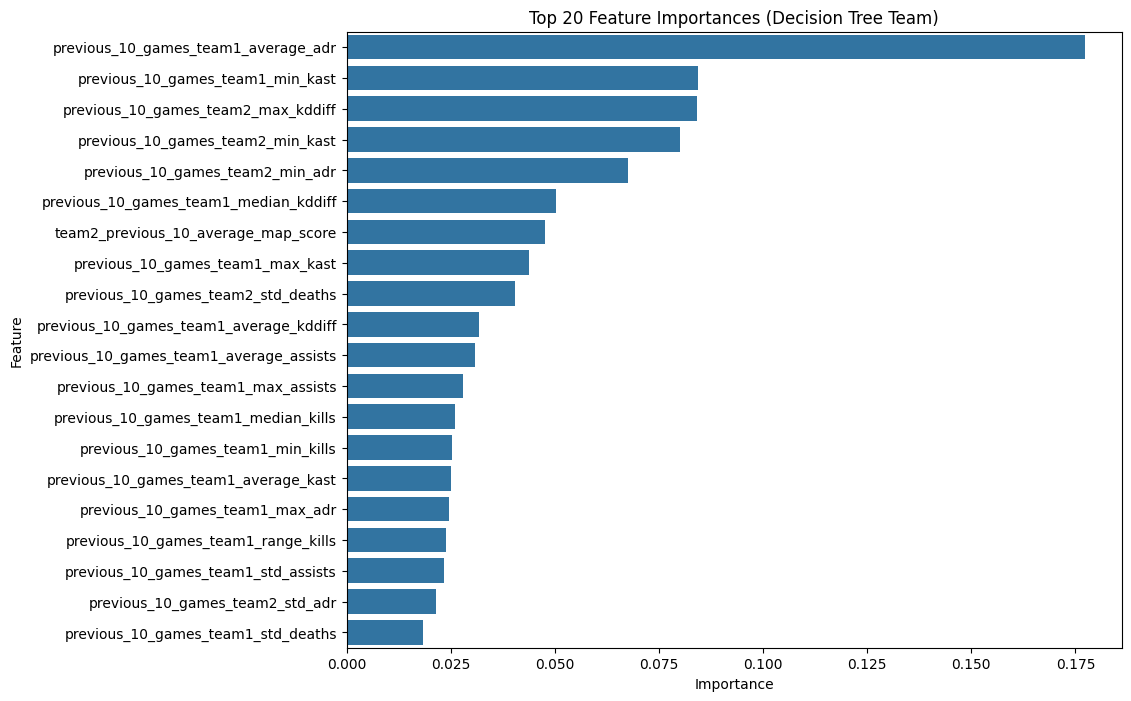

In [7]:
# Feature Importance
importances = clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances (Decision Tree Team)')
plt.show()

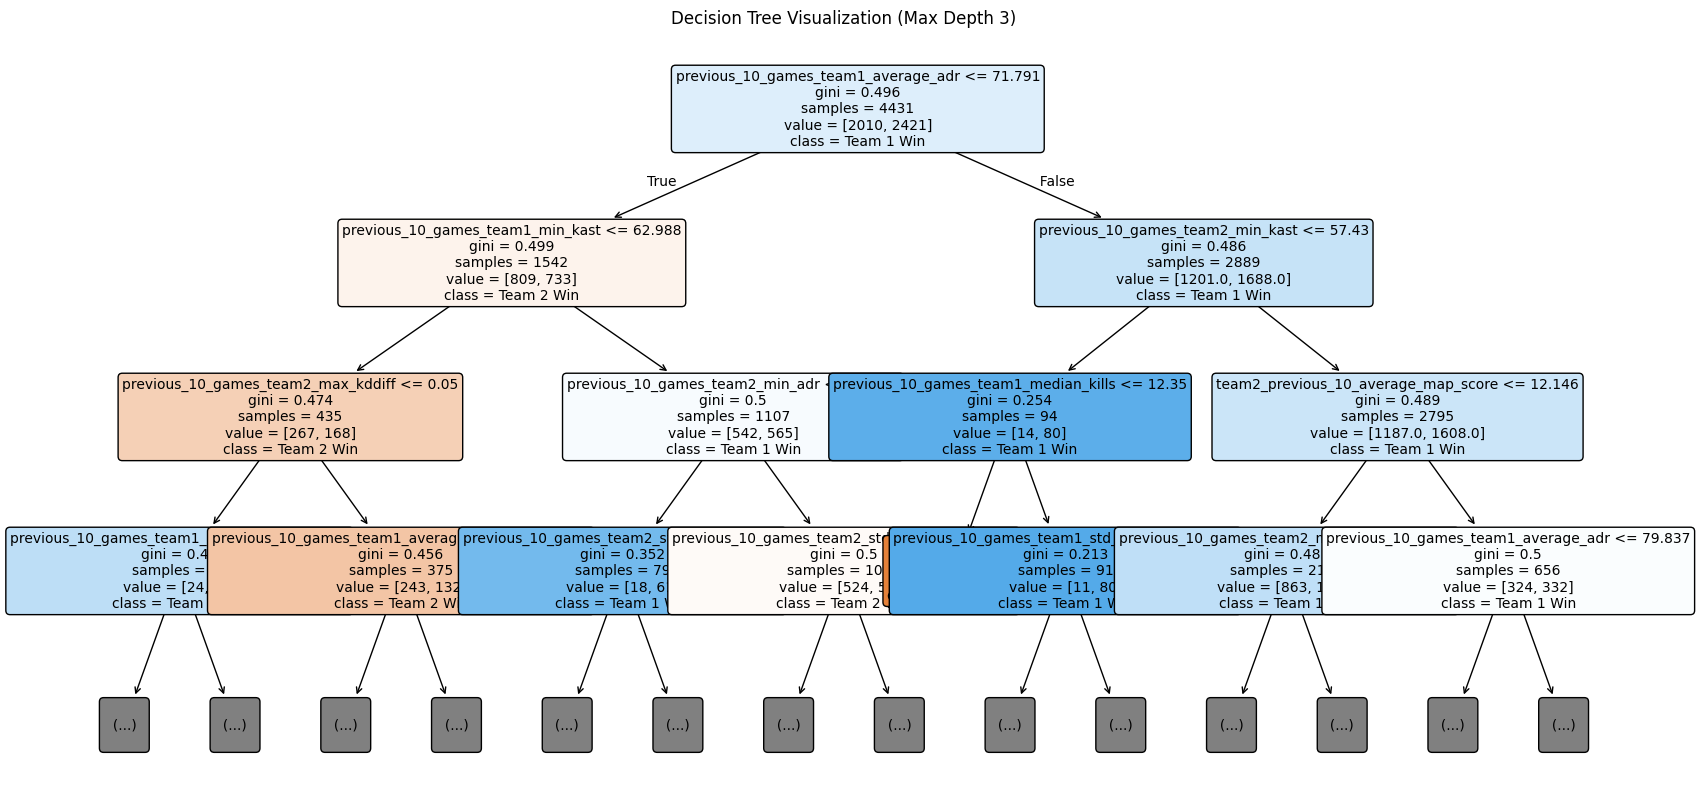

In [8]:
# Visualize the Decision Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['Team 2 Win', 'Team 1 Win'], 
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3)
plt.title('Decision Tree Visualization (Max Depth 3)')
plt.show()